<a href="https://colab.research.google.com/github/frostd1022/neur_256_spring26/blob/main/Practice_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dave Frost

*Intro to Nerual Data Analysis*

**4/28/26**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url1 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_hits_hw6.csv'
acc_hits = np.loadtxt(url1, delimiter = ',')

url2 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_fa_hw6.csv'
acc_fa = np.loadtxt(url2, delimiter = ',')

url3 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_hits_hw6.csv'
lc_hits = np.loadtxt(url3, delimiter = ',')

url4 = 'https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_fa_hw6.csv'
lc_fa = np.loadtxt(url4, delimiter = ',')

In [4]:
print(acc_hits.shape)
print(acc_fa.shape)
print(lc_hits.shape)
print(lc_fa.shape)


(14, 8001)
(19, 8001)
(14, 8001)
(19, 8001)


In [6]:
time = np.linspace(0, 4, 8001)

In [7]:
sampling_rate = 8001/4

Text(0, 0.5, 'Frequency (Hz)')

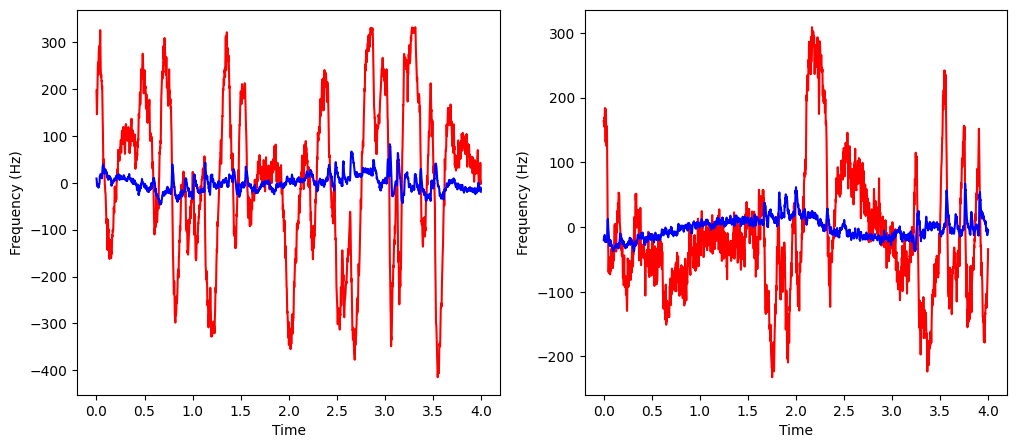

In [18]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(time,acc_hits[0], color = 'red')
ax[0].plot(time,lc_hits[0], color = 'blue')

ax[1].plot(time,acc_fa[0], color = 'red')
ax[1].plot(time,lc_fa[0], color = 'blue')

ax[0].set_xlabel('Time')
ax[0].set_ylabel('Frequency (Hz)')

ax[1].set_xlabel('Time')
ax[1].set_ylabel('Frequency (Hz)')


Lowk think the data swapped lol

In [19]:
dt = time[1] - time[0]              # Define the sampling interval.
K = acc_hits.shape[0]               # Define the number of trials.
N = acc_hits.shape[1]               # Define number of points in each trial.
ac = np.zeros([2 * N - 1])

Text(0.5, 1.0, 'Coherence between two electrodes')

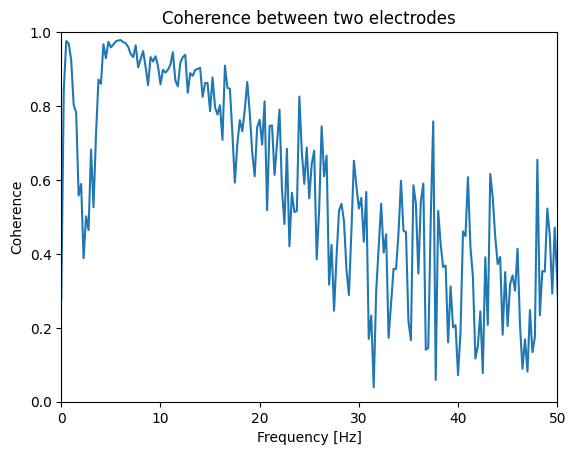

In [20]:
xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_hits])  # ... for each trial in E1
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_hits])  # ... and each trial in E2

# Compute the spectra
T = time[-1]
scale = 2 * dt**2 / T
Sxx = scale * (xf * xf.conj()).mean(0)  # Spectrum of E1 trials
Syy = scale * (yf * yf.conj()).mean(0)  # ... and E2 trials
Sxy = scale * (xf * yf.conj()).mean(0)  # ... and the cross spectrum

# Compute the coherence.
cohr = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

f = np.fft.rfftfreq(N, dt)                     # Define a frequency axis.
plt.plot(f, cohr.real)                      # Plot coherence vs frequency,
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                            # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')

Frequency band that has the highest coherence is between 7-8

Text(0.5, 1.0, 'Coherence between two electrodes')

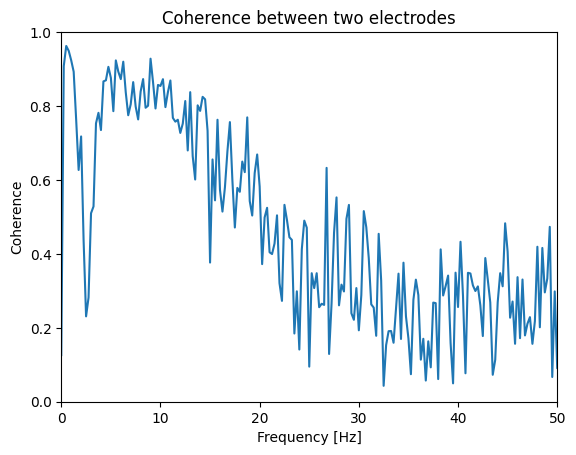

In [21]:
xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_fa])  # ... for each trial in E1
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_fa])  # ... and each trial in E2

# Compute the spectra
T = time[-1]
scale = 2 * dt**2 / T
Sxx = scale * (xf * xf.conj()).mean(0)  # Spectrum of E1 trials
Syy = scale * (yf * yf.conj()).mean(0)  # ... and E2 trials
Sxy = scale * (xf * yf.conj()).mean(0)  # ... and the cross spectrum

# Compute the coherence.
cohr = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

f = np.fft.rfftfreq(N, dt)                     # Define a frequency axis.
plt.plot(f, cohr.real)                      # Plot coherence vs frequency,
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                            # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')